# Computación Gráfica - CC431A

---


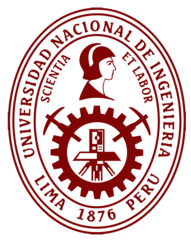
---

### Profesor: Peter Jonathan Montalvo Garcia
---
# TEMA: DETECCION DE OBJETOS - MODELO YOLO 11
---
---

## TIPO DE MODELO EN YOLO

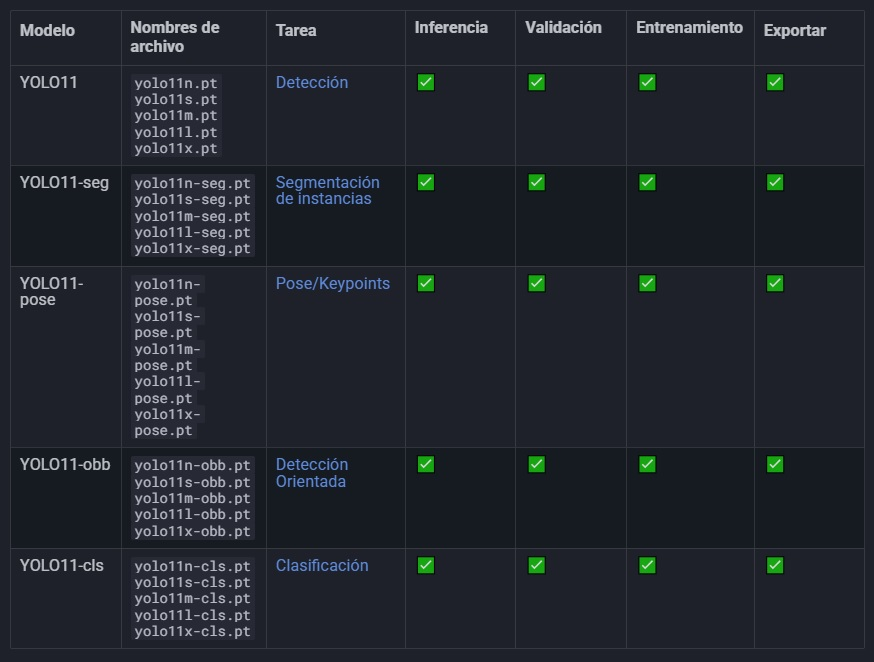

# Deteccion de Objetos [1]
Detecta objetos en una imagen en particular fija. Se usa los parametros del propio modelo para identificar

In [1]:
from ultralytics import YOLO
import os

# Obtener el directorio actual del script
script_dir = os.getcwd()

# Ruta local al modelo YOLO
model_path = os.path.join(script_dir, "yolo11n.pt")

# cargar modelo YOLO 11 nano pt(deteccion)
model = YOLO(model_path)

# path de la imagen donde se aplicara la deteccion, solo una imagen a la vez
print("[INFO] Ruta: ",script_dir)
source = os.path.join(script_dir, "Imagen_Deteccion", "persona_01.jpg")

# realizamos la prediccion con YOLO de la imagen
result=model(source)
print(result) # se visualiza x terminal

# visualizamos el resultado, solo una imagen
result[0].show()
print("[INFO] FIN DEL PROGRAMA ..........")


ModuleNotFoundError: No module named 'ultralytics'

# Deteccion de Objetos [2]
Detecta objetos en cuatro imagenes en particular fija. Se usa los parametros del propio modelo para identificar

In [5]:
from ultralytics import YOLO
import os

# Obtener el directorio actual del script
#script_dir = os.path.dirname(os.path.abspath(__file__))
script_dir = os.getcwd()

# Ruta local al modelo YOLO
model_path = os.path.join(script_dir, "yolo11n.pt")

# cargar modelo YOLO 11 nano pt(deteccion)
model = YOLO(model_path)

# Lista de nombres de imágenes
image_names = ["persona_01.jpg", "persona_02.jpg", "persona_03.jpg", "persona_04.jpg"]

# Por esta (porque Imagen_Deteccion está dentro de MODELO_YOLO):
image_folder = os.path.join(script_dir, "Imagen_Deteccion")
image_paths = [os.path.join(image_folder, name) for name in image_names]

# Normalizar rutas (opcional pero útil)
image_paths = [os.path.normpath(path) for path in image_paths]

# Mostrar rutas para verificar
for path in image_paths:
    print("[INFO] Imagen a procesar:", path)

# Realizar la detección
print("\n[INFO] Resultado de procesamiento")
results = model(image_paths)

# visualizamos el resultado, todas las imagenes
for result in results:
    print("========================================================================================================")
    print(result.boxes)
    result.show()

print("[INFO] FIN DEL PROGRAMA ..........")

[INFO] Imagen a procesar: d:\YOLO_FINAL\CODIGOS_PYTHON\[2]_DETECCION\Imagen_Deteccion\persona_01.jpg
[INFO] Imagen a procesar: d:\YOLO_FINAL\CODIGOS_PYTHON\[2]_DETECCION\Imagen_Deteccion\persona_02.jpg
[INFO] Imagen a procesar: d:\YOLO_FINAL\CODIGOS_PYTHON\[2]_DETECCION\Imagen_Deteccion\persona_03.jpg
[INFO] Imagen a procesar: d:\YOLO_FINAL\CODIGOS_PYTHON\[2]_DETECCION\Imagen_Deteccion\persona_04.jpg

[INFO] Resultado de procesamiento

0: 640x640 3 persons, 2 traffic lights, 78.9ms
1: 640x640 5 persons, 6 cars, 78.9ms
2: 640x640 1 person, 2 cats, 78.9ms
3: 640x640 3 persons, 4 bicycles, 78.9ms
Speed: 3.8ms preprocess, 78.9ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)
ultralytics.engine.results.Boxes object with attributes:

cls: tensor([0., 0., 0., 9., 9.])
conf: tensor([0.9081, 0.9053, 0.8080, 0.7250, 0.5710])
data: tensor([[4.9655e+02, 1.4115e+02, 6.8741e+02, 4.6620e+02, 9.0808e-01, 0.0000e+00],
        [2.7989e+02, 1.2473e+02, 4.5634e+02, 5.3169e+02, 9.0532e-01

# Deteccion de Objetos [3]
Detecta objetos en una imagene en particular fija, usando OpenCV y se manipula las coordenadas de la caja delimitadora. Se usa los parametros del propio modelo para identificar

In [6]:
from ultralytics import YOLO
import os
import cv2

# Obtener el directorio actual del script
script_dir = os.getcwd()

# Ruta local al modelo YOLO
model_path = os.path.join(script_dir, "yolo11n.pt")

# cargar modelo YOLO 11 nano pt(deteccion)
model = YOLO(model_path)

# Cargamos la imagen de entrada de donde lee openCV
image_path = os.path.join(script_dir, "Imagen_Deteccion", "persona_01.jpg")
image = cv2.imread(image_path)

# Realizamos la inferencia sobre la imagen
results = model(image)

for result in results:
    # Extraemos los nombres de las clases detectadas
    names = [result.names[int(label)] for label in result.boxes.cls]
    # Extraemos las coordenadas de las cajas delimitadoras
    print("\n[INFO] IMPRESION DE CAJAS DELIMITADORA\n")
    xyxys = result.boxes.xyxy
    for i, xyxy in enumerate(xyxys):
        print(f"[INFO] Caja Obj[{i}]: {names[i]}")
        x1, y1 = int(xyxy[0]), int(xyxy[1])
        print("[INFO] Punto Superior: (", x1,",",y1,")")
        x2, y2 = int(xyxy[2]), int(xyxy[3])
        print("[INFO] Punto Inferior: (", x2,",",y2,")\n")
        # Dibujar la caja
        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 255), 2)
        # Poner la etiqueta
        texto = f"Obj[{i}]: {names[i]}"
        cv2.putText(image, texto, (x1, y1 - 5), 1, 1.1, (0, 0, 255), 2)
        
    # Mostrar la imagen con las detecciones
    cv2.imshow("Deteccion de Objetos [3] - Presiona 'q' para Salir", image)
    cv2.waitKey(0)
cv2.destroyAllWindows()

print("[INFO] FIN DEL PROGRAMA ..........")


0: 512x640 3 persons, 2 traffic lights, 61.6ms
Speed: 2.8ms preprocess, 61.6ms inference, 1.0ms postprocess per image at shape (1, 3, 512, 640)

[INFO] IMPRESION DE CAJAS DELIMITADORA

[INFO] Caja Obj[0]: person
[INFO] Punto Superior: ( 496 , 141 )
[INFO] Punto Inferior: ( 687 , 466 )

[INFO] Caja Obj[1]: person
[INFO] Punto Superior: ( 280 , 124 )
[INFO] Punto Inferior: ( 456 , 530 )

[INFO] Caja Obj[2]: person
[INFO] Punto Superior: ( 122 , 86 )
[INFO] Punto Inferior: ( 251 , 518 )

[INFO] Caja Obj[3]: traffic light
[INFO] Punto Superior: ( 320 , 14 )
[INFO] Punto Inferior: ( 378 , 100 )

[INFO] Caja Obj[4]: traffic light
[INFO] Punto Superior: ( 285 , 36 )
[INFO] Punto Inferior: ( 317 , 120 )

[INFO] FIN DEL PROGRAMA ..........


# Deteccion de Objetos [4]
Detecta objetos de un video en particular fijo, usando OpenCV. Se usa los parametros del propio modelo para identificar

In [8]:
from ultralytics import YOLO
import os
import cv2

# Obtener el directorio actual del script
script_dir = os.getcwd()

# Ruta local al modelo YOLO
model_path = os.path.join(script_dir, "yolo11n.pt")

# cargar modelo YOLO 11 nano pt(deteccion)
model = YOLO(model_path)

# path de la imagen donde se aplicara la deteccion
print("Ruta: ",script_dir)
#video_path="./MODELO_YOLO/Imagen_Deteccion/video.mp4"
video_path=os.path.join(script_dir, "Imagen_Deteccion", "video_2.mp4") 

#cargamos el video de la ruta asignada
cap=cv2.VideoCapture(video_path)

while cap.isOpened():
    # leemos el frame del video
    ret, frame=cap.read()
    if not ret:
        break

    # realizamos la inferencia de YOLO sobre el frame
    results=model(frame)

    # extraemos los resultados
    annotated_frame=results[0].plot()

    # visualizamos los resultados
    cv2.imshow("Deteccion de Objetos [4] - Presiona 'q' para Salir",annotated_frame)

    # el ciclo se rompe al presionar ESC
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

print("[INFO] FIN DEL PROGRAMA ..........")

Ruta:  d:\YOLO_FINAL\CODIGOS_PYTHON\[2]_DETECCION

0: 384x640 10 cars, 1 truck, 48.4ms
Speed: 2.3ms preprocess, 48.4ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 10 cars, 1 truck, 74.1ms
Speed: 2.3ms preprocess, 74.1ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 8 cars, 1 truck, 78.7ms
Speed: 73.1ms preprocess, 78.7ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 9 cars, 47.9ms
Speed: 1.6ms preprocess, 47.9ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 8 cars, 44.6ms
Speed: 1.4ms preprocess, 44.6ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 7 cars, 45.3ms
Speed: 1.4ms preprocess, 45.3ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 8 cars, 68.4ms
Speed: 1.6ms preprocess, 68.4ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 8 cars, 61.5ms
Speed: 1.5ms preprocess, 

# Deteccion de Objetos [5]
Detecta objetos de la camara de la computadora usando el OpenCV. Se usa los parametros del propio modelo para identificar

In [10]:
from ultralytics import YOLO
import os
import cv2

# Obtener el directorio actual del script
# script_dir = os.path.dirname(os.path.abspath(__file__))
script_dir = os.getcwd()

# Ruta local al modelo YOLO
model_path = os.path.join(script_dir, "yolo11n.pt")

# cargar modelo YOLO 11 nano pt(deteccion)
model = YOLO(model_path)

#cargamos el video del webcam
cap=cv2.VideoCapture(0)

while cap.isOpened():
    # leemos el frame del video
    ret, frame=cap.read()
    if not ret:
        break

    # realizamos la inferencia de YOLO sobre el frame
    results=model(frame)

    # extraemos los resultados
    annotated_frame=results[0].plot()

    # visualizamos los resultados
    cv2.imshow("Deteccion de Objetos [5] - Presiona 'q' para Salir",annotated_frame)

    # el ciclo se rompe al presionar ESC
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

print("[INFO] FIN DEL PROGRAMA ..........")


0: 480x640 1 person, 60.3ms
Speed: 2.4ms preprocess, 60.3ms inference, 0.9ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 69.6ms
Speed: 1.6ms preprocess, 69.6ms inference, 0.9ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 71.3ms
Speed: 1.4ms preprocess, 71.3ms inference, 0.9ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 53.8ms
Speed: 1.0ms preprocess, 53.8ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 74.9ms
Speed: 1.2ms preprocess, 74.9ms inference, 0.9ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 67.9ms
Speed: 1.0ms preprocess, 67.9ms inference, 0.9ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 47.4ms
Speed: 1.5ms preprocess, 47.4ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 51.8ms
Speed: 1.4ms preprocess, 51.8ms inference, 0.9ms postprocess per image at shape (1, 3, 48

# Deteccion de Objetos [6]
Detecta multiple objetos, con diferentes camaras, las cuales estan conectadas e instaladas en la computadora donde se ejecute el script, se usa para esto el OpenCV. Se usa los parametros del propio modelo para identificar

In [12]:
from ultralytics import YOLO
import os
import cv2

# cargar el modelo YOLO 
script_dir = os.getcwd()
model_path = os.path.join(script_dir, "yolo11n.pt")
model = YOLO(model_path)

# función para detectar cámaras disponibles 
def detectar_camaras(max_test=10):
    camaras_disponibles = []
    for i in range(max_test):
        cap = cv2.VideoCapture(i)
        if cap is not None and cap.isOpened():
            camaras_disponibles.append(i)
            cap.release()
    return camaras_disponibles

# detectar todas las cámaras 
ids_camaras = detectar_camaras()
print(f"[INFO]  Camaras encontradas: {ids_camaras}")

# abrir todas las camaras 
capturas = [cv2.VideoCapture(i) for i in ids_camaras]

#  ciclo principal 
while True:
    for i, cap in enumerate(capturas):
        ret, frame = cap.read()
        if not ret:
            continue

        # inferencia YOLO
        results = model(frame)
        annotated = results[0].plot()

        # mostrar en ventana separada por cámara
        cv2.imshow(f"Camara {i}, presiona 'q' para Salir - Deteccion de Objetos [6]", annotated)

    # Salir con tecla 'q'
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# liberar recursos 
for cap in capturas:
    cap.release()
cv2.destroyAllWindows()

print("[INFO] FIN DEL PROGRAMA ..........")

[INFO]  Camaras encontradas: [0, 1, 2]

0: 480x640 1 person, 70.9ms
Speed: 1.9ms preprocess, 70.9ms inference, 0.9ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 3 books, 60.8ms
Speed: 1.8ms preprocess, 60.8ms inference, 0.9ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 78.4ms
Speed: 7.8ms preprocess, 78.4ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 55.2ms
Speed: 1.2ms preprocess, 55.2ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 2 books, 75.1ms
Speed: 1.4ms preprocess, 75.1ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 2 persons, 1 tv, 1 toothbrush, 52.8ms
Speed: 1.0ms preprocess, 52.8ms inference, 0.9ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 70.7ms
Speed: 1.3ms preprocess, 70.7ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 3 books, 67.1ms
Sp